Objetivo:
Construir modelos de clasificación para predecir churn de clientes a partir de variables de comportamiento (RFM), comparando un modelo base (Logistic Regression) con un modelo más complejo (XGBoost).

Librerias

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    precision_recall_curve, f1_score, precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
!pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Cargar dataset

In [2]:
df = pd.read_csv('/content/drive/MyDrive/PI_LV/data/processed/clientes_churn.csv')
# df = df_cliente.copy()

NameError: name 'pd' is not defined

In [2]:
from pathlib import Path

In [3]:
import re

import pandas as pd

In [4]:
DATA_PATH = Path('../data/processed/clientes_churn.csv')

if not DATA_PATH.exists():
    DATA_PATH = Path('/mnt/data/clientes_churn.csv')

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(80355, 25)


,cliente_id_new,fecha_primera_compra,fecha_ultima_compra,recency,frequency,monetary,tenure_days,active_month_ratio,avg_ticket,std_ticket,...,spend_trend_70,descuento_porc_promedio,ratio_descuento_sobre_venta,margen_pct,dias_promedio_vencimiento,flag_credito,churn_60,churn_70,churn_90,churn
0,1027461,2024-05-08,2025-02-28,307,5,1970.18,296,0.300000,394.03600,256.588208,...,0.000000,5.600000,0.089847,0.514021,0.0,0.0,1,1,1,1
1,1089134,2025-02-06,2025-12-31,1,20,17891.83,328,1.000000,894.59150,687.827867,...,0.069911,13.835327,0.175732,0.503229,0.0,0.0,0,0,0,0
2,1089187,2024-02-19,2025-12-08,24,31,7418.34,658,0.782609,239.30129,180.339686,...,-0.561248,11.661290,0.131741,0.440145,0.0,0.0,0,0,0,0
3,1111859,2024-10-16,2025-12-18,14,20,3583.75,428,0.866667,179.18750,99.518539,...,-0.490060,12.583333,0.162716,0.490562,0.0,0.0,0,0,0,0
4,1133970,2024-04-08,2025-12-04,28,8,937.10,605,0.333333,117.13750,72.922652,...,79.440000,8.625000,0.136548,0.369825,0.0,0.0,0,0,0,0


## 2. Definir target y excluir variables con fuga

In [5]:
target = 'churn'

excluir_fuga = [
    'cliente_id_new',
    'fecha_primera_compra',
    'fecha_ultima_compra',
    'churn_60',
    'churn_70',
    'churn_90',
    'churn',
    'recency'
]

excluir_muy_cercanas = [
    'compras_70d',
    'gasto_70d',
    'spend_trend_70'
]

excluir_total = excluir_fuga + excluir_muy_cercanas

features = [c for c in df.columns if c not in excluir_total]

X = df[features].copy()
y = df[target].copy()

print("Número de variables:", len(features))
print(features)

Número de variables: 14
['frequency', 'monetary', 'tenure_days', 'active_month_ratio', 'avg_ticket', 'std_ticket', 'total_galones', 'avg_days_between', 'max_gap_days', 'descuento_porc_promedio', 'ratio_descuento_sobre_venta', 'margen_pct', 'dias_promedio_vencimiento', 'flag_credito']


## 3. Revisar nulos y tipo de variables

In [6]:
print("Tipos de datos:")
print(X.dtypes.value_counts())

print("\nDetalle de tipos por variable:")
print(X.dtypes.sort_index())

nulos_resumen = pd.DataFrame({
    'tipo_dato': X.dtypes,
    'n_nulos': X.isna().sum(),
    'pct_nulos': (X.isna().mean() * 100).round(2)
}).sort_values(by='pct_nulos', ascending=False)

print("\nResumen de nulos por variable:")
display(nulos_resumen)

print("\nResumen estadístico:")
display(X.describe().T)

Tipos de datos:
float64    12
int64       2
Name: count, dtype: int64

Detalle de tipos por variable:
active_month_ratio             float64
avg_days_between               float64
avg_ticket                     float64
descuento_porc_promedio        float64
dias_promedio_vencimiento      float64
flag_credito                   float64
frequency                        int64
margen_pct                     float64
max_gap_days                   float64
monetary                       float64
ratio_descuento_sobre_venta    float64
std_ticket                     float64
tenure_days                      int64
total_galones                  float64
dtype: object

Resumen de nulos por variable:


,tipo_dato,n_nulos,pct_nulos
frequency,int64,0,0.0
monetary,float64,0,0.0
tenure_days,int64,0,0.0
active_month_ratio,float64,0,0.0
avg_ticket,float64,0,0.0
std_ticket,float64,0,0.0
total_galones,float64,0,0.0
avg_days_between,float64,0,0.0
max_gap_days,float64,0,0.0
descuento_porc_promedio,float64,0,0.0



Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
frequency,80355.0,19.047365,28.365734,1.000000,3.000000,8.000000,24.000000,1.347000e+03
monetary,80355.0,18187.321448,113203.977162,2.020000,827.255000,3419.350000,12718.745000,1.824115e+07
tenure_days,80355.0,584.540514,522.922450,0.000000,82.000000,437.000000,1116.000000,1.456000e+03
active_month_ratio,80355.0,0.649303,0.291190,0.041667,0.400000,0.666667,1.000000,1.000000e+00
avg_ticket,80355.0,886.357394,2915.413482,2.020000,187.910152,353.673333,810.705489,3.712467e+05
std_ticket,80355.0,599.930981,7186.116225,0.000000,47.283910,169.173548,544.628147,1.959611e+06
total_galones,80355.0,429.837735,3563.256955,0.000000,19.008000,80.260400,307.671400,6.008774e+05
avg_days_between,80355.0,57.319926,86.416747,0.000000,14.000000,33.200000,67.857143,1.454000e+03
max_gap_days,80355.0,145.553979,162.478425,0.000000,37.000000,102.000000,196.000000,1.454000e+03
descuento_porc_promedio,80355.0,8.398286,5.512488,0.000000,4.642857,7.902327,11.454986,6.480000e+01


Se eliminó la variable flag_credito del conjunto de predictores porque presentó varianza nula: todos los registros tomaban el mismo valor. En consecuencia, no aportaba capacidad discriminativa para diferenciar clientes churn y no churn, por lo que su inclusión no generaría valor en el modelado

In [7]:
features = [
    'frequency',
    'monetary',
    'tenure_days',
    'active_month_ratio',
    'avg_ticket',
    'std_ticket',
    'total_galones',
    'avg_days_between',
    'max_gap_days',
    'descuento_porc_promedio',
    'ratio_descuento_sobre_venta',
    'margen_pct',
    'dias_promedio_vencimiento'
]

X = df[features].copy()
y = df[target].copy()

### 3.1. Resumen de outliers con IQR

In [8]:
resumen_outliers = []

for col in X.columns:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((X[col] < lower) | (X[col] > upper)).sum()
    pct_outliers = n_outliers / len(X) * 100

    resumen_outliers.append({
        'variable': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'lower_bound': lower,
        'upper_bound': upper,
        'n_outliers': n_outliers,
        'pct_outliers': round(pct_outliers, 2)
    })

resumen_outliers = pd.DataFrame(resumen_outliers).sort_values(by='pct_outliers', ascending=False)
resumen_outliers

,variable,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers
12,dias_promedio_vencimiento,0.000000,0.000000,0.000000,0.000000,0.000000,19173,23.86
1,monetary,827.255000,12718.745000,11891.490000,-17009.980000,30555.980000,9564,11.90
6,total_galones,19.008000,307.671400,288.663400,-413.987100,740.666500,9320,11.60
4,avg_ticket,187.910152,810.705489,622.795337,-746.282855,1744.898495,8909,11.09
5,std_ticket,47.283910,544.628147,497.344236,-698.732444,1290.644501,8228,10.24
0,frequency,3.000000,24.000000,21.000000,-28.500000,55.500000,6679,8.31
7,avg_days_between,14.000000,67.857143,53.857143,-66.785714,148.642857,6455,8.03
8,max_gap_days,37.000000,196.000000,159.000000,-201.500000,434.500000,4621,5.75
11,margen_pct,0.439420,0.532242,0.092822,0.300186,0.671475,4157,5.17
10,ratio_descuento_sobre_venta,0.050661,0.144448,0.093787,-0.090019,0.285128,2178,2.71


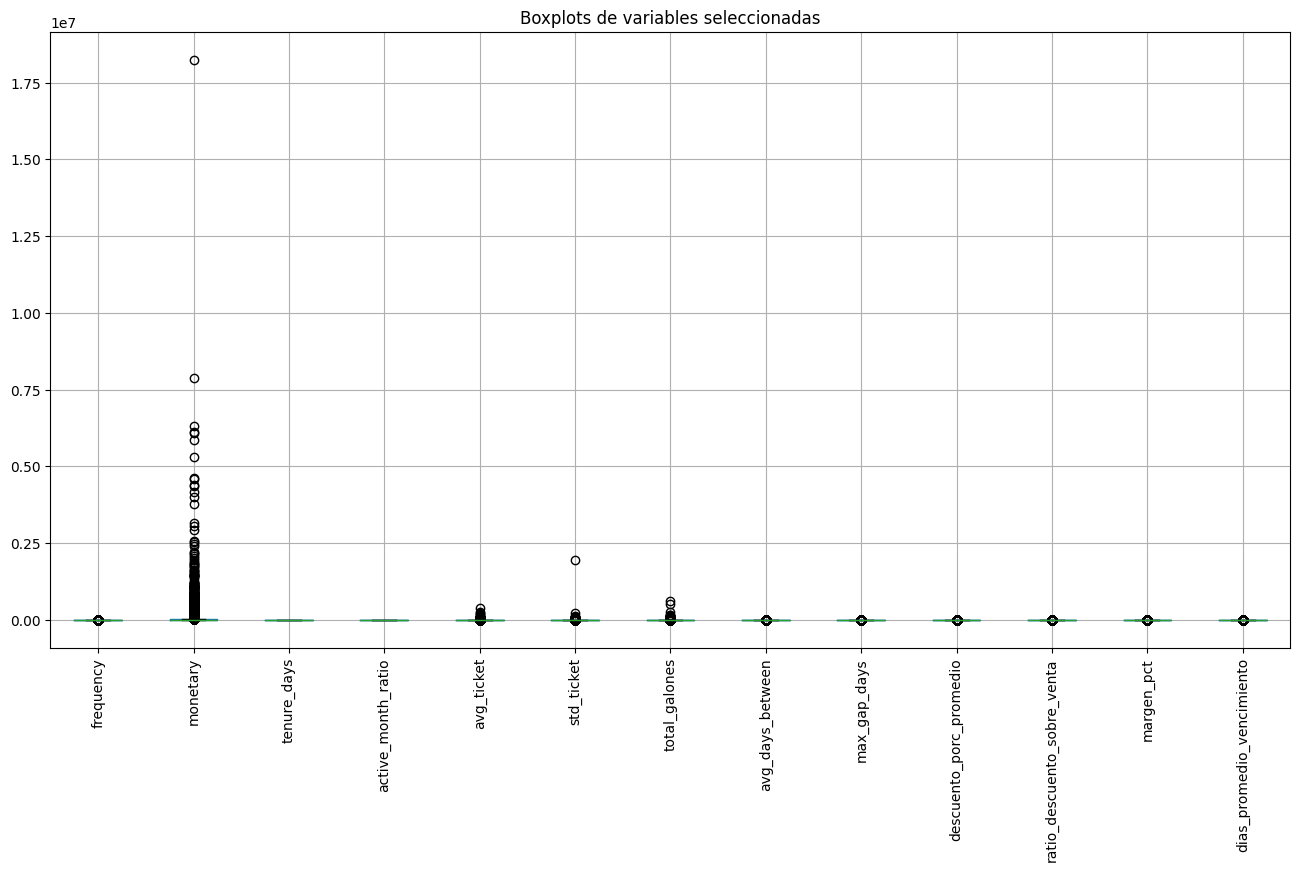

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
X.boxplot(rot=90)
plt.title('Boxplots de variables seleccionadas')
plt.show()

## 4. Split estratificado

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Distribución y_train (conteos):")
print(y_train.value_counts())

print("\nDistribución y_train (proporciones):")
print(y_train.value_counts(normalize=True))

print("\nDistribución y_test (conteos):")
print(y_test.value_counts())

print("\nDistribución y_test (proporciones):")
print(y_test.value_counts(normalize=True))

Distribución y_train (conteos):
churn
1    36281
0    28003
Name: count, dtype: int64

Distribución y_train (proporciones):
churn
1    0.564386
0    0.435614
Name: proportion, dtype: float64

Distribución y_test (conteos):
churn
1    9070
0    7001
Name: count, dtype: int64

Distribución y_test (proporciones):
churn
1    0.564371
0    0.435629
Name: proportion, dtype: float64


## 4.1. Split Log

In [ ]:
cols_skewed = ['frequency', 'monetary', 'avg_ticket', 'std_ticket', 'total_galones']

X_log = X.copy()
for col in cols_skewed:
    X_log[col] = np.log1p(X_log[col])

X_log[cols_skewed].describe().T

,count,mean,std,min,25%,50%,75%,max
frequency,80355.0,2.306114,1.176206,0.693147,1.386294,2.197225,3.218876,7.206377
monetary,80355.0,8.085851,1.903624,1.105257,6.719321,8.137498,9.450911,16.719191
avg_ticket,80355.0,6.001222,1.136910,1.105257,5.241272,5.871197,6.699138,12.824625
std_ticket,80355.0,4.621091,2.430373,0.000000,3.877098,5.136819,6.301938,14.488257
total_galones,80355.0,4.374372,1.850515,0.000000,2.996132,4.397659,5.732277,13.306148


In [ ]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## **Modelo 1 : Logistic Regression**

## 5.Baseline fuerte: Logistic Regression

In [ ]:
pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ))
])

pipe_lr.fit(X_train_log, y_train_log)

y_pred_lr = pipe_lr.predict(X_test_log)
y_proba_lr = pipe_lr.predict_proba(X_test_log)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test_log, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test_log, y_proba_lr))
print("Confusion matrix:\n", confusion_matrix(y_test_log, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.68      0.75      0.71      7001
           1       0.79      0.73      0.76      9070

    accuracy                           0.74     16071
   macro avg       0.74      0.74      0.74     16071
weighted avg       0.74      0.74      0.74     16071

ROC-AUC: 0.8216003242252209
Confusion matrix:
 [[5233 1768]
 [2409 6661]]


5.1. Interpretación de coeficientes LR

In [ ]:
coef_lr = pd.DataFrame({
    'feature': X_train_log.columns,
    'coef': pipe_lr.named_steps['model'].coef_[0]
}).sort_values('coef', ascending=False)

print("Variables que más aumentan la probabilidad de churn:")
display(coef_lr.head(10))

print("Variables que más reducen la probabilidad de churn:")
display(coef_lr.tail(10))

Variables que más aumentan la probabilidad de churn:


,feature,coef
0,frequency,3.465767
4,avg_ticket,3.454243
8,max_gap_days,0.177726
12,dias_promedio_vencimiento,0.132544
10,ratio_descuento_sobre_venta,0.102934
5,std_ticket,0.001919
7,avg_days_between,-0.115600
11,margen_pct,-0.577331
9,descuento_porc_promedio,-0.582155
3,active_month_ratio,-0.587721


Variables que más reducen la probabilidad de churn:


,feature,coef
12,dias_promedio_vencimiento,0.132544
10,ratio_descuento_sobre_venta,0.102934
5,std_ticket,0.001919
7,avg_days_between,-0.115600
11,margen_pct,-0.577331
9,descuento_porc_promedio,-0.582155
3,active_month_ratio,-0.587721
2,tenure_days,-0.994631
6,total_galones,-1.357078
1,monetary,-4.243280


Interpretación del modelo

Accuracy = 0.74: el modelo acierta 74% del total.
ROC-AUC = 0.822: buena capacidad de discriminación entre churn y no churn.
Clase 1 (churn):
Precision = 0.79: cuando predice churn, acierta bastante.
Recall = 0.73: identifica 73% de los churn reales.
F1 = 0.76: desempeño equilibrado.
Clase 0 (no churn):
Precision = 0.68
Recall = 0.75
F1 = 0.71
Matriz de confusión
5233 no churn bien clasificados
1768 no churn clasificados como churn
6661 churn bien clasificados
2409 churn no detectados

Eso significa que el modelo está detectando bastante bien el churn, aunque todavía deja escapar una parte de clientes churn reales.

La regresión logística mostró un desempeño satisfactorio como modelo base, alcanzando un ROC-AUC de 0.822 y un F1-score de 0.76 para la clase churn. Esto sugiere que las variables seleccionadas permiten discriminar razonablemente entre clientes con y sin riesgo de abandono. Entre las variables con mayor asociación positiva al churn destacan la frecuencia, el ticket promedio y el máximo intervalo entre compras, mientras que variables como gasto total, galones consumidos, antigüedad del cliente y estabilidad mensual mostraron asociación negativa. No obstante, la interpretación de coeficientes se realizó con cautela debido a posibles efectos de colinealidad entre predictores

## **Modelo 2: Random Forest**

## 6. Random Forest

In [ ]:
pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_rf.fit(X_train, y_train)

y_pred_rf = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.74      0.72      0.73      7001
           1       0.79      0.81      0.80      9070

    accuracy                           0.77     16071
   macro avg       0.77      0.76      0.77     16071
weighted avg       0.77      0.77      0.77     16071

ROC-AUC: 0.854244196017359
Confusion matrix:
 [[5028 1973]
 [1722 7348]]


Importancia de variables RF

In [ ]:
imp_rf = pd.DataFrame({
    'feature': features,
    'importance': pipe_rf.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

imp_rf.head(20)

,feature,importance
0,frequency,0.255065
2,tenure_days,0.246699
6,total_galones,0.070223
1,monetary,0.068736
8,max_gap_days,0.060334
7,avg_days_between,0.059615
9,descuento_porc_promedio,0.052101
11,margen_pct,0.048763
10,ratio_descuento_sobre_venta,0.041256
3,active_month_ratio,0.029816


El modelo Random Forest superó al baseline de regresión logística, alcanzando un ROC-AUC de 0.854 y un F1-score de 0.80 para la clase churn. Además, mostró una mejora importante en recall, elevándolo a 0.81, lo que indica una mayor capacidad para detectar clientes con riesgo de abandono. Las variables más relevantes para el modelo fueron la frecuencia de compra, la antigüedad del cliente, el volumen consumido en galones, el gasto acumulado y los intervalos máximos entre compras, lo que refuerza la importancia de las dimensiones de intensidad, valor y regularidad temporal en la predicción del churn

## **Modelo 3: XGBoost**

## 7. XGBoost

In [10]:
pipe_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

pipe_xgb.fit(X_train, y_train)

y_pred_xgb = pipe_xgb.predict(X_test)
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.79      0.70      0.74      7001
           1       0.78      0.85      0.82      9070

    accuracy                           0.78     16071
   macro avg       0.78      0.77      0.78     16071
weighted avg       0.78      0.78      0.78     16071

ROC-AUC: 0.86932863741154
Confusion matrix:
 [[4875 2126]
 [1335 7735]]


7.1. Importancia de variables XGBoost

In [11]:
imp_xgb = pd.DataFrame({
    'feature': features,
    'importance': pipe_xgb.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

imp_xgb.head(20)

,feature,importance
0,frequency,0.437053
2,tenure_days,0.198402
3,active_month_ratio,0.051439
9,descuento_porc_promedio,0.048643
7,avg_days_between,0.048219
11,margen_pct,0.034365
12,dias_promedio_vencimiento,0.034362
6,total_galones,0.032139
10,ratio_descuento_sobre_venta,0.029426
4,avg_ticket,0.028662


XGBoost fue el modelo con mejor desempeño predictivo, alcanzando un ROC-AUC de 0.869 y un F1-score de 0.82 para la clase churn. Además, obtuvo un recall de 0.85, lo que evidencia una alta capacidad para identificar clientes con riesgo de abandono. Las variables más influyentes fueron la frecuencia de compra, la antigüedad del cliente, la estabilidad mensual, el descuento promedio y el intervalo medio entre compras, lo que sugiere que el churn en este contexto está más asociado a la recurrencia y estabilidad del comportamiento que al gasto bruto aislado

## **Comparación de Modelos**

Comparación de modelos

In [ ]:
results = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC_AUC': [
        roc_auc_score(y_test_log, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ],
    'F1': [
        f1_score(y_test_log, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test_log, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test_log, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ]
}).sort_values('ROC_AUC', ascending=False)

results

,Modelo,ROC_AUC,F1,Precision,Recall
2,XGBoost,0.869328,0.818196,0.784695,0.854686
1,Random Forest,0.854244,0.799087,0.788327,0.810143
0,Logistic Regression,0.821600,0.761301,0.790248,0.734399


XGBoost es el más conveniente porque tiene el mayor recall, o sea identifica más clientes churn reales.
Además mantiene una precision razonable, así que no sacrifica demasiado al detectar más casos.

## 8. Ajuste de threshold para XGBoost

In [11]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

Best threshold: 0.41884494
Best F1: 0.823836275587525


Threshold óptimo = 0.4212
El modelo considera churn con un corte más bajo que 0.5.
Best F1 = 0.8236
Mejora un poco el equilibrio entre precisión y recall respecto al umbral estándar.

Aplicar threshold óptimo:

In [12]:
y_pred_xgb_opt = (y_proba_xgb >= best_threshold).astype(int)

print("=== XGBoost con threshold optimizado ===")
print(classification_report(y_test, y_pred_xgb_opt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_xgb_opt))

=== XGBoost con threshold optimizado ===
              precision    recall  f1-score   support

           0       0.84      0.62      0.71      7001
           1       0.76      0.91      0.82      9070

    accuracy                           0.78     16071
   macro avg       0.80      0.76      0.77     16071
weighted avg       0.79      0.78      0.78     16071

ROC-AUC: 0.86932863741154
Confusion matrix:
 [[4347 2654]
 [ 858 8212]]


Tras seleccionar XGBoost como mejor modelo, se optimizó el umbral de clasificación utilizando la curva precision-recall y el criterio de máximo F1. El threshold óptimo fue 0.421, con lo cual el recall de la clase churn aumentó de 0.85 a 0.90, reduciendo significativamente los falsos negativos. Aunque esta decisión implicó una ligera disminución en precisión, resultó más adecuada para un contexto de retención, donde es preferible identificar la mayor cantidad posible de clientes en riesgo

## 9. Validación Cruzada

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

cv_results_xgb = cross_validate(
    pipe_xgb,
    X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

pd.DataFrame(cv_results_xgb).agg(['mean', 'std']).T

,mean,std
fit_time,4.139137,0.894060
score_time,0.468955,0.233032
test_roc_auc,0.867504,0.002506
test_f1,0.818651,0.001643
test_precision,0.784745,0.003445
test_recall,0.855637,0.002940


La validación cruzada estratificada de 5 folds confirmó la robustez del modelo XGBoost. El modelo alcanzó un ROC-AUC promedio de 0.8675, un F1 promedio de 0.8187, una precision promedio de 0.7847 y un recall promedio de 0.8556. La baja variabilidad entre folds sugiere que el desempeño es estable y que el modelo presenta buena capacidad de generalización.

## 10. Análisis de clientes de alto riesgo

In [ ]:
test_scored = X_test.copy()
test_scored['y_true'] = y_test.values
test_scored['score_churn'] = y_proba_xgb
test_scored['pred_churn'] = y_pred_xgb_opt

test_scored = test_scored.sort_values('score_churn', ascending=False)

test_scored.head(20)

,frequency,monetary,tenure_days,active_month_ratio,avg_ticket,std_ticket,total_galones,avg_days_between,max_gap_days,descuento_porc_promedio,ratio_descuento_sobre_venta,margen_pct,dias_promedio_vencimiento,y_true,score_churn,pred_churn
947,1.098612,9.007818,5,1.0,8.314793,6.485180,5.489386,5.0,5.0,0.000000,0.000000,0.000306,15.000000,1,0.998128,1
20863,1.098612,9.469010,0,1.0,8.775940,8.928148,6.325183,0.0,0.0,0.000000,0.000000,0.008046,30.000000,1,0.998029,1
29626,0.693147,9.103504,0,1.0,9.103504,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.041803,31.000000,0,0.997898,1
5177,0.693147,7.306236,0,1.0,7.306236,0.000000,3.912991,0.0,0.0,0.000000,0.000000,0.035387,30.000000,1,0.997701,1
26641,1.098612,9.128506,11,1.0,8.435468,8.615160,0.000000,11.0,11.0,0.000000,0.000000,-0.489302,0.000000,1,0.996758,1
6606,0.693147,5.993961,0,1.0,5.993961,0.000000,0.000000,0.0,0.0,0.000000,0.000000,-2.096554,0.000000,1,0.996290,1
19446,0.693147,7.576564,0,1.0,7.576564,0.000000,3.828641,0.0,0.0,0.000000,0.000000,0.316545,30.000000,1,0.996085,1
26074,0.693147,8.214554,0,1.0,8.214554,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.074605,0.000000,1,0.995841,1
6935,0.693147,8.180769,0,1.0,8.180769,0.000000,4.844187,0.0,0.0,0.000000,0.000000,0.240700,60.000000,0,0.995828,1
14409,1.386294,10.273265,15,1.0,9.174722,8.888249,6.406880,7.5,14.0,0.000000,0.000000,0.295078,0.000000,1,0.995765,1


top 10% de riesgo

In [ ]:
top_10_pct = int(len(test_scored) * 0.10)
top_10 = test_scored.head(top_10_pct)

top_10.shape

(1607, 16)

Cuanto churn real captura en ese top 10%

In [ ]:
captura_top10 = top_10['y_true'].sum() / test_scored['y_true'].sum()
print("Churn capturado en top 10%:", round(captura_top10, 4))

Churn capturado en top 10%: 0.1713


No está mal, pero tampoco es una concentración muy alta.
Eso sugiere que el churn no está hiperconcentrado en un grupo pequeño, sino más repartido en la población.

In [15]:
df_scored = df.copy()

df_scored['score_churn'] = pipe_xgb.predict_proba(X)[:, 1]
df_scored['pred_churn'] = (df_scored['score_churn'] >= best_threshold).astype(int)

df_scored[['cliente_id_new', 'score_churn', 'pred_churn']].head()

,cliente_id_new,score_churn,pred_churn
0,1027461,0.688902,1
1,1089134,0.144226,0
2,1089187,0.442597,1
3,1111859,0.201553,0
4,1133970,0.744322,1


In [16]:
df_scored.to_csv('/content/drive/MyDrive/PI_LV/data/processed/clientes_churn_scored.csv', index=False)

In [ ]:
import pickle

Path("models").mkdir(exist_ok=True)

# Guardar pipeline completo de XGBoost
with open("models/xgb_model.pkl", "wb") as f:
    pickle.dump(pipe_xgb, f)

# Guardar threshold óptimo
with open("models/threshold.pkl", "wb") as f:
    pickle.dump(best_threshold, f)

print("✅ Modelo XGBoost guardado en models/xgb_model.pkl")
print(f"✅ Threshold guardado en models/threshold.pkl: {best_threshold:.4f}")
print(f"📁 Ubicación: {Path('models').absolute()}")